# Image-to-video dRSA

Loads one `preprocessed_natraster.mat` file made by `first_preprocessing.m`, aligns neural image/video responses with sequential model features, and computes image static dRSA and video cross-temporal dRSA.

In [2]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import yaml

def find_project_root(start_path: Path) -> Path:
    """Return the nearest parent directory containing config.yaml."""
    for path in (start_path, *start_path.parents):
        if (path / 'config.yaml').exists():
            return path
    # end for path
    raise FileNotFoundError('Could not find config.yaml from the notebook working directory.')
# EOF


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')

with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
)
from project_specific_utils import (
    min_max_normalization,
)
from useful_stuff.general_utils import TimeSeries, create_RDM, decode_matlab_strings, get_lagplot, get_lagplot_subset
from useful_stuff.general_utils.RSA import dRSA


In [3]:
@dataclass
class Cfg:
    exp_name = "paul_20260901" # "baby1_260716"

    # MATLAB channels 84--186 inclusive; Python stop indices are exclusive.
    good_channels: tuple[int, int] = (84, 186)
    image_crop_ms: int = 1000
    new_fs: float | None = 100  # Set to None to keep the original 1000 Hz.
    normalization: str | None = None  # Supported: None or 'min_max'.

    signal_RDM_metric: str = 'cosine_cnt'
    model_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'spearman'
    video_RSA_metric: str = 'correlation'
    video_lag_analysis_end_ms: float = 2500
    video_max_lag_ms: float = 700

    model_name: str = 'ijepa_vith14_1k'
    model_dataset_name: str = 'static_dynamic'
    model_pooling: str | None = 'mean'
    model_features_dir: Path | None = None


cfg = Cfg()
cfg
natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.exp_name}_natraster.mat'


In [4]:
def stimulus_key(stimulus_name: str) -> str:
    """Return the shared identity after removing the img_/vid_ stimulus prefix."""
    filename_stem = Path(stimulus_name).stem
    for prefix in ('img_', 'vid_'):
        if filename_stem.startswith(prefix):
            return filename_stem[len(prefix):]
        # end if filename_stem.startswith(prefix)
    # end for prefix
    raise ValueError(f'Stimulus does not start with img_ or vid_: {stimulus_name}')
# EOF


def load_natraster(mat_path: Path) -> tuple[np.ndarray, list[str]]:
    """
    load_natraster
    Load MATLAB v7.3 rasters and their unique stimulus names.

    INPUT:
        - mat_path: Path -> `preprocessed_natraster.mat` output path.

    OUTPUT:
        - rasters: np.ndarray -> channels x time x stimuli.
        - stimulus_names: list[str] -> stimulus filename for each raster.
    """
    with h5py.File(mat_path, 'r') as file:
        # h5py exposes MATLAB's v7.3 arrays in reverse dimension order.
        rasters = file['natraster'][:].transpose(2, 1, 0).astype(np.float32)
        stimulus_names = decode_matlab_strings(file, file['uniqueImage'][:])
    # end with h5py.File
    return rasters, stimulus_names
# EOF


def split_sort_and_match_rasters(
        rasters: np.ndarray, stimulus_names: list[str],
        ) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Split img_/vid_ rasters, then align their shared identities in sorted order."""
    image_indices = {stimulus_key(name): index for index, name in enumerate(stimulus_names)
                     if Path(name).stem.startswith('img_')}
    video_indices = {stimulus_key(name): index for index, name in enumerate(stimulus_names)
                     if Path(name).stem.startswith('vid_')}
    common_keys = sorted(image_indices.keys() & video_indices.keys())

    if len(common_keys) < 2:
        raise ValueError('Need at least two shared stimuli. Check file paths and stimulus_key().')
    # end if len(common_keys)

    image_order = [image_indices[key] for key in common_keys]
    video_order = [video_indices[key] for key in common_keys]
    return rasters[:, :, image_order], rasters[:, :, video_order], common_keys
# EOF


In [5]:
rasters, stimulus_names = load_natraster(natraster_mat_path)
image_rasters, video_rasters, shared_stimuli = split_sort_and_match_rasters(
    rasters, stimulus_names,
)

first_channel, last_channel = cfg.good_channels
channel_slice = slice(first_channel - 1, last_channel)
image_rasters = image_rasters[channel_slice, :cfg.image_crop_ms, :]
video_rasters = video_rasters[channel_slice, :, :]
image_ts = TimeSeries(image_rasters[17:25, :, :], fs=1000)
#image_ts = TimeSeries(image_rasters[:, :, :], fs=1000)
video_ts = TimeSeries(video_rasters[17:25, :, :], fs=1000)
# video_ts = TimeSeries(video_rasters[:, :, :], fs=1000)

if cfg.new_fs is not None:
    image_ts.resample(cfg.new_fs)
    video_ts.resample(cfg.new_fs)
# end if cfg.new_fs

if cfg.normalization == 'min_max':
    # Estimate one set of channel bounds so image and video remain comparable.
    normalization_reference = np.concatenate([
        image_ts.get_array().reshape(image_ts.shape()[0], -1),
        video_ts.get_array().reshape(video_ts.shape()[0], -1),
    ], axis=1)
    image_ts.set_array(min_max_normalization(
        image_ts.get_array(), reference_data=normalization_reference,
    ))
    video_ts.set_array(min_max_normalization(
        video_ts.get_array(), reference_data=normalization_reference,
    ))
elif cfg.normalization is not None:
    raise ValueError("cfg.normalization must be None or 'min_max'")
# end if cfg.normalization == 'min_max'


print(f'{len(shared_stimuli)} shared stimuli')
print(f'Image raster: {image_ts.shape()} (channels, time, stimuli)')
print(f'Video raster: {video_ts.shape()} (channels, time, stimuli)')
print(f'Sampling frequency: {video_ts.get_fs()} Hz')


ValueError: Need at least two shared stimuli. Check file paths and stimulus_key().

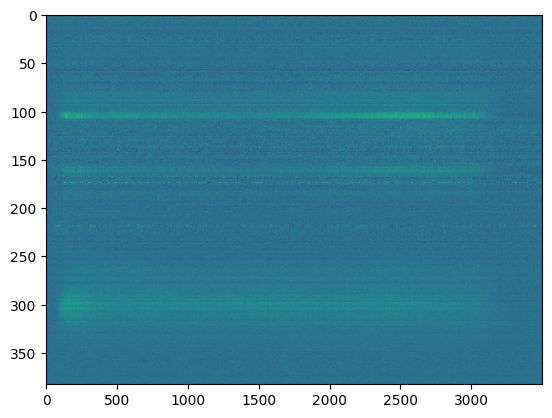

In [131]:
plt.imshow(np.mean(rasters, axis=2), aspect="auto")

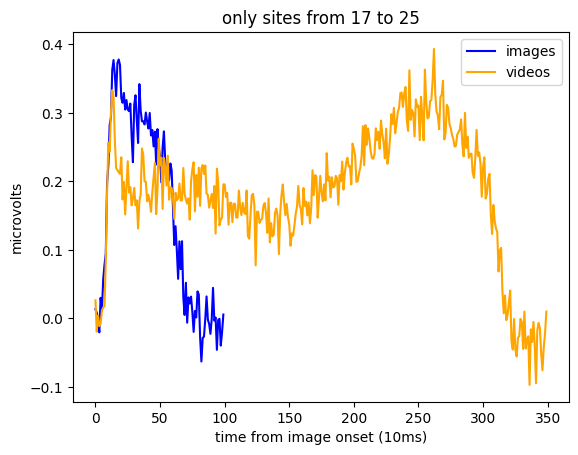

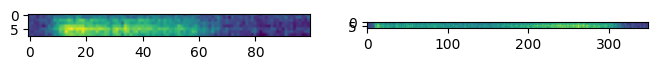

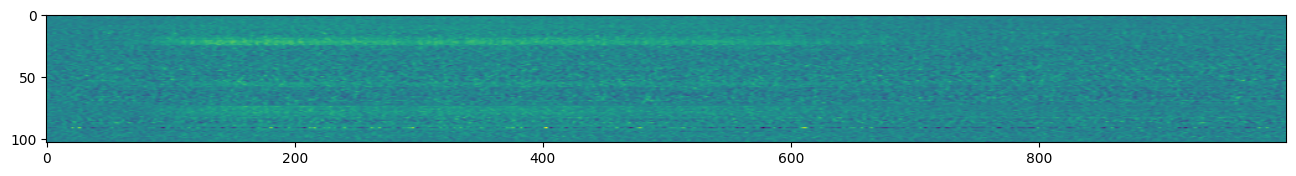

In [111]:
plt.plot(np.mean(image_ts.array[:, :, :], axis=(0,2)).T, color="blue", label="images")
plt.plot(np.mean(video_ts.array[:, :, :], axis=(0,2)).T, color="orange", label="videos")
plt.title("only sites from 17 to 25")
plt.ylabel("microvolts")
plt.xlabel("time from image onset (10ms)")
plt.legend()
fig, ax = plt.subplots(1,2, figsize=(8,10))
ax[0].imshow(np.mean(image_ts.array, axis=2))
ax[1].imshow(np.mean(video_ts.array, axis=2))
fig = plt.figure(figsize=(16,18))
plt.imshow(np.mean(image_rasters, axis=2))


In [112]:
running_sum = None
for i in range(video_ts.shape()[2]):
    v = TimeSeries(video_ts.array[:,:,i], cfg.new_fs)
    i = TimeSeries(image_ts.array[:,:,i], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i)
    else:
        running_sum += v.lagged_corr(i)

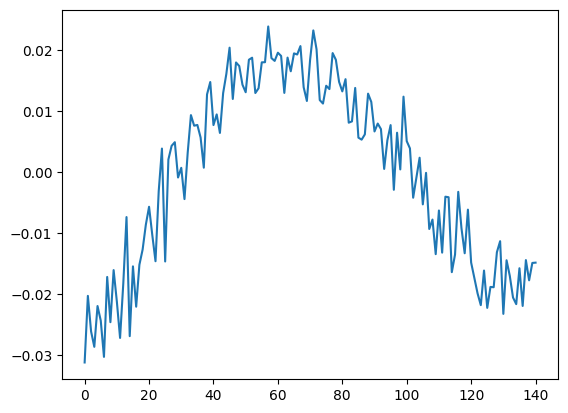

In [113]:
# plt.imshow(running_sum/video_ts.shape()[2])
plt.plot(get_lagplot(running_sum[250:, :]/video_ts.shape()[2], max_lag=70))

In [114]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
drsa.compute_both_RDM_timeseries(video_ts, image_ts)
corr_mat = drsa.compute_dRSA()

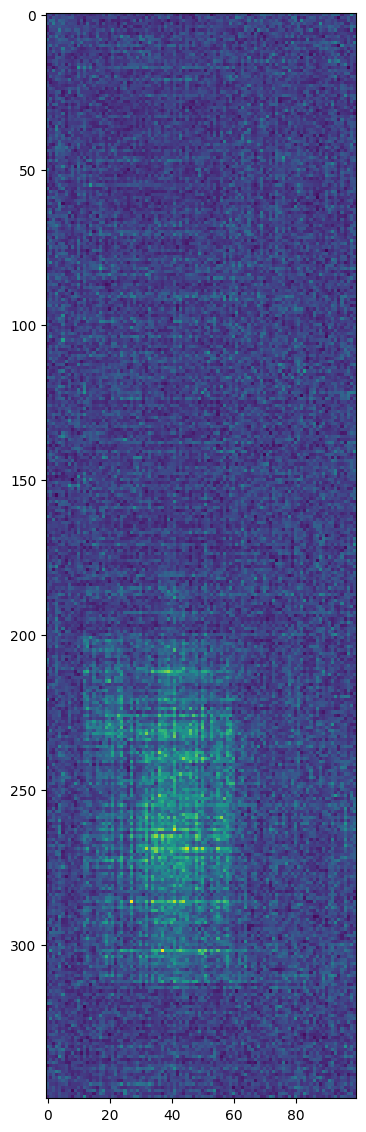

In [115]:
plt.figure(figsize=(4, 16))
plt.imshow(corr_mat)


Text(0.5, 1.0, 'static to dynamic lagplot')

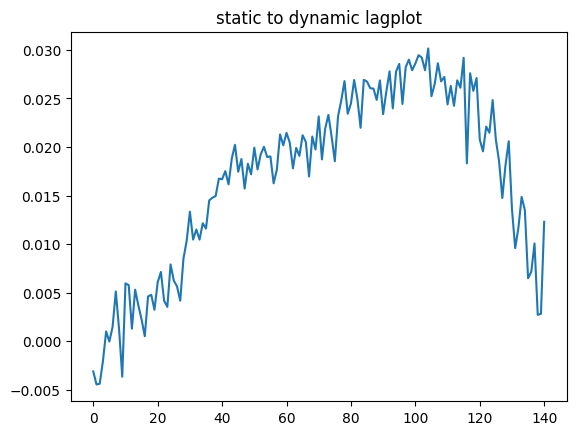

In [132]:
plt.plot(get_lagplot(corr_mat[200:300, :], max_lag=70))
plt.title("static to dynamic lagplot")

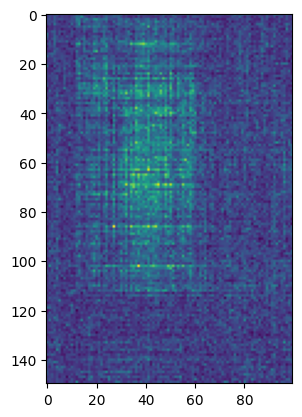

In [117]:

plt.imshow(corr_mat[200:, :])


In [118]:
# Load all extracted model layers in numeric order (layer 0, 1, ..., 23).
model_features_dir = cfg.model_features_dir or Path(paths['data_path']) / 'models'
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)

# Keep every neural image and video that has a corresponding extracted feature set.
image_indices_all = [index for index, name in enumerate(stimulus_names)
                     if Path(name).stem.startswith('img_')]
video_indices_all = [index for index, name in enumerate(stimulus_names)
                     if Path(name).stem.startswith('vid_')]
image_names_all = [Path(stimulus_names[index]).name for index in image_indices_all]
video_names_all = [Path(stimulus_names[index]).name for index in video_indices_all]
image_model_names = [f'vid_{stimulus_key(name)}{Path(name).suffix}'
                     for name in image_names_all]

image_neural_ts = TimeSeries(
    rasters[channel_slice, :cfg.image_crop_ms, image_indices_all], fs=1000,
)
video_neural_ts = TimeSeries(
    rasters[channel_slice, :, video_indices_all], fs=1000,
)
if cfg.new_fs is not None:
    image_neural_ts.resample(cfg.new_fs)
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

if cfg.normalization == 'min_max':
    # Re-estimate shared bounds using every condition included in the model analyses.
    normalization_reference = np.concatenate([
        image_neural_ts.get_array().reshape(image_neural_ts.shape()[0], -1),
        video_neural_ts.get_array().reshape(video_neural_ts.shape()[0], -1),
    ], axis=1)
    image_neural_ts.set_array(min_max_normalization(
        image_neural_ts.get_array(), reference_data=normalization_reference,
    ))
    video_neural_ts.set_array(min_max_normalization(
        video_neural_ts.get_array(), reference_data=normalization_reference,
    ))
# end if cfg.normalization == 'min_max'

print(f'{len(feature_paths)} model layers')
print(f'{len(image_names_all)} image stimuli aligned to final-frame model features')
print(f'{len(video_names_all)} video stimuli aligned to sequential model features')

32 model layers
88 image stimuli aligned to final-frame model features
89 video stimuli aligned to sequential model features


## Static dRSA: neural image timecourse versus the final DINO frame

The final extracted frame of each corresponding `vid_` stimulus is used as the static model representation of its `img_` stimulus. All 88 neural image conditions are retained.

In [119]:
image_neural_ts.shape()

(103, 100, 88)

In [120]:
image_neural_ts.__len__()

100

In [121]:
# Compute the neural image RDM once because it is shared by every model layer.
image_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
image_neural_ts = TimeSeries(image_neural_ts.array[17:25, :, :], cfg.new_fs)
image_drsa.compute_RDM_timeseries(image_neural_ts, 'signal')

image_layer_drsa = []
layer_names = []
for feature_path in feature_paths:
    # The final frame has the same visual content as the corresponding static image.
    final_frame_features, layer_name, _ = load_aligned_video_features(
        feature_path, image_model_names, frame_index=-1,
    )
    model_RDM = create_RDM(final_frame_features, metric=cfg.model_RDM_metric)
    image_drsa.set_RDM(model_RDM, 'model')
    image_layer_drsa.append(image_drsa.compute_static_dRSA().get_array().copy())
    layer_names.append(layer_name)
# end for feature_path

image_layer_drsa = np.stack(image_layer_drsa, axis=0)
print(f'Image static dRSA: {image_layer_drsa.shape} (layers, neural time)')

Image static dRSA: (32, 100) (layers, neural time)


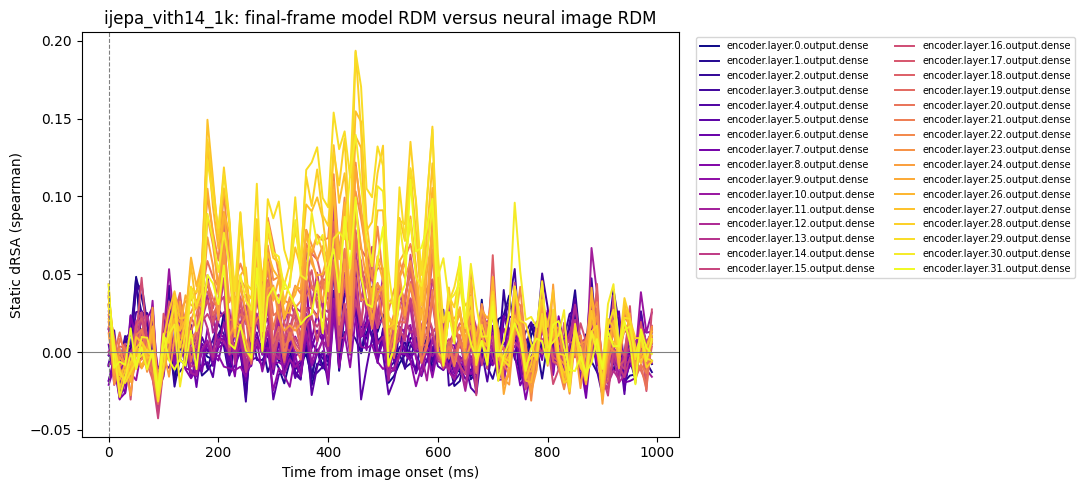

In [122]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))

fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=1.4, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'{cfg.model_name}: final-frame model RDM versus neural image RDM')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()

## Video dRSA: neural video timecourse versus sequential DINO features

All 89 neural video conditions and all extracted model frames are retained. Each result is a neural-time by model-time cross-temporal dRSA matrix.

In [ ]:
# Compute the neural video RDM once, then replace only the model RDM timecourse.
video_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.video_RSA_metric,
)
video_neural_ts = TimeSeries(video_neural_ts.array[17:25, :, :], cfg.new_fs)
video_drsa.compute_RDM_timeseries(video_neural_ts, 'signal')

video_layer_drsa = {}
source_model_fs = None
for feature_path in feature_paths:
    model_features, layer_name, layer_model_fs = load_aligned_video_features(
        feature_path, video_names_all, frame_index=None,
    )

    # Match the model and neural time grids before computing the model RDM timecourse.
    model_ts = TimeSeries(model_features, fs=layer_model_fs)
    model_ts.resample(video_neural_ts.get_fs())
    video_drsa.compute_RDM_timeseries(model_ts, 'model')
    video_layer_drsa[layer_name] = video_drsa.compute_dRSA().copy()

    if source_model_fs is None:
        source_model_fs = layer_model_fs
    elif source_model_fs != layer_model_fs:
        raise ValueError('Model layers have inconsistent source frame rates.')
    # end if source_model_fs is None
# end for feature_path

model_fs = video_neural_ts.get_fs()
example_layer = layer_names[12]
example_video_drsa = video_layer_drsa[example_layer]
neural_time_ms = np.arange(example_video_drsa.shape[0]) * 1000 / video_neural_ts.get_fs()
model_time_ms = np.arange(example_video_drsa.shape[1]) * 1000 / model_fs
print(
    f'{example_layer} video dRSA: {example_video_drsa.shape} (neural time, model time); '
    f'model features resampled from {source_model_fs:g} to {model_fs:g} Hz'
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    example_video_drsa, aspect='auto', origin='upper', cmap='coolwarm',
    extent=[model_time_ms[0], model_time_ms[-1],
            neural_time_ms[-1], neural_time_ms[0]],
)
ax.set(xlabel='Model video time (ms)', ylabel='Neural video time (ms)',
       title=f'{cfg.model_name} {example_layer} video dRSA')
fig.colorbar(image, ax=ax, label=f'dRSA ({cfg.video_RSA_metric})')
fig.tight_layout()

In [ ]:
# Both dRSA axes now share one sampling rate, so use the standard diagonal utility.
lag_fs = video_neural_ts.get_fs()
analysis_end_index = int(np.ceil(cfg.video_lag_analysis_end_ms * lag_fs / 1000))
max_lag_samples = int(round(cfg.video_max_lag_ms * lag_fs / 1000))
lag_ms = np.arange(-max_lag_samples, max_lag_samples + 1) * 1000 / lag_fs

video_layer_lagplots = []
for layer_name in layer_names:
    layer_drsa = video_layer_drsa[layer_name]
    neural_idx = np.arange(min(analysis_end_index, layer_drsa.shape[0]))
    model_idx = np.arange(min(analysis_end_index, layer_drsa.shape[1]))
    layer_lagplot = get_lagplot_subset(
        layer_drsa,
        neural_idx=neural_idx,
        model_idx=model_idx,
        max_lag=max_lag_samples,
    )
    video_layer_lagplots.append(layer_lagplot)
# end for layer_name
video_layer_lagplots = np.stack(video_layer_lagplots, axis=0)

layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_lagplot) in enumerate(
        zip(layer_names, video_layer_lagplots),
        ):
    ax.plot(
        lag_ms, layer_lagplot, color=layer_colors[layer_index],
        linewidth=1.4, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(
    xlabel='Lag: neural time - model time (ms)',
    ylabel=f'Mean dRSA ({cfg.video_RSA_metric})',
    title=(f'{cfg.model_name} video dRSA lagplots; '
           f'times < {cfg.video_lag_analysis_end_ms / 1000:g} s'),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()